In [93]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [94]:
data = pd.read_csv("../data/processed/Ambazari_Nagpur_Feature_Engineering_Dataset_2024_2025.csv")

data["timestamp"] = pd.to_datetime(data["timestamp"])

data = data.sort_values("timestamp").reset_index(drop=True)

In [95]:
print("Shape:", data.shape)

print("\nDate range:")
print(data["timestamp"].min(), "to", data["timestamp"].max())

print("\nMissing values:", data.isnull().sum().sum())

print("Duplicate timestamps:", data["timestamp"].duplicated().sum())

Shape: (17519, 70)

Date range:
2024-01-02 00:00:00 to 2025-12-31 22:00:00

Missing values: 0
Duplicate timestamps: 0


In [96]:
print(data.columns.tolist())

['timestamp', 'pm25', 'pm10', 'no2', 'so2', 'co', 'o3', 'temperature', 'humidity', 'wind_speed', 'wind_direction', 'weather_code', 'hour', 'day', 'day_of_week', 'month', 'year', 'is_weekend', 'season', 'pm25_lag_1', 'pm25_lag_3', 'pm25_lag_6', 'pm25_lag_12', 'pm25_lag_24', 'pm10_lag_1', 'pm10_lag_6', 'pm10_lag_24', 'no2_lag_1', 'no2_lag_6', 'no2_lag_24', 'so2_lag_1', 'so2_lag_6', 'so2_lag_24', 'co_lag_1', 'co_lag_6', 'co_lag_24', 'o3_lag_1', 'o3_lag_6', 'o3_lag_24', 'pm25_rolling_mean_3', 'pm25_rolling_mean_6', 'pm25_rolling_mean_12', 'pm25_rolling_mean_24', 'pm10_rolling_mean_3', 'pm10_rolling_mean_6', 'pm10_rolling_mean_24', 'no2_rolling_mean_3', 'no2_rolling_mean_6', 'no2_rolling_mean_24', 'so2_rolling_mean_3', 'so2_rolling_mean_6', 'so2_rolling_mean_24', 'co_rolling_mean_3', 'co_rolling_mean_6', 'co_rolling_mean_24', 'o3_rolling_mean_3', 'o3_rolling_mean_6', 'o3_rolling_mean_24', 'wind_direction_sin', 'wind_direction_cos', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'target_p

In [97]:
pollutants = ["pm25", "pm10", "no2", "so2", "co", "o3"]
data[pollutants].describe().T

,count,mean,std,min,25%,50%,75%,max
pm25,17519.0,46.214853,27.094381,0.05,24.65,42.00,63.270,487.48
pm10,17519.0,91.284261,46.002413,6.19,56.60,86.38,117.550,832.54
no2,17519.0,21.054186,19.182815,0.01,9.02,15.16,25.550,177.75
so2,17519.0,16.949561,18.080676,0.02,8.11,11.86,18.295,198.76
co,17519.0,0.644574,0.540577,0.00,0.33,0.48,0.730,7.63
o3,17519.0,35.941865,32.437745,0.00,9.86,25.97,53.260,187.86


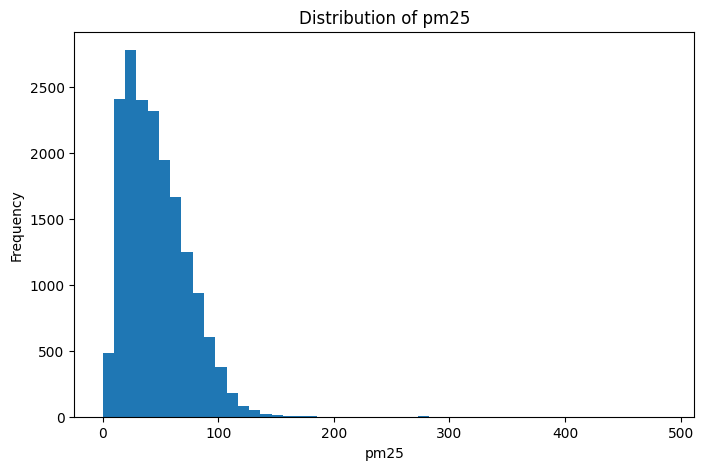

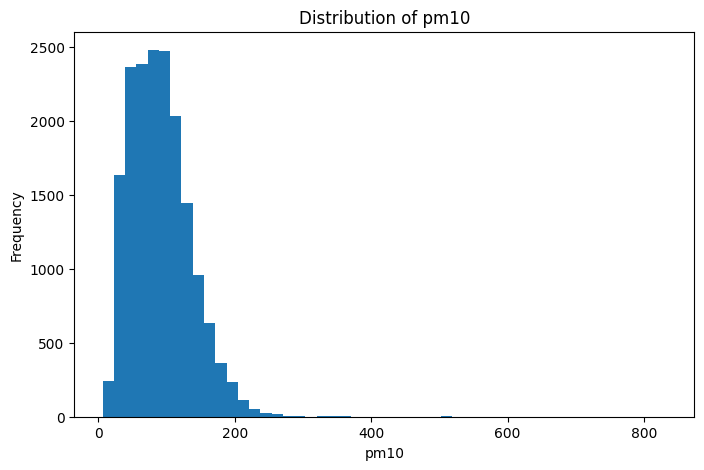

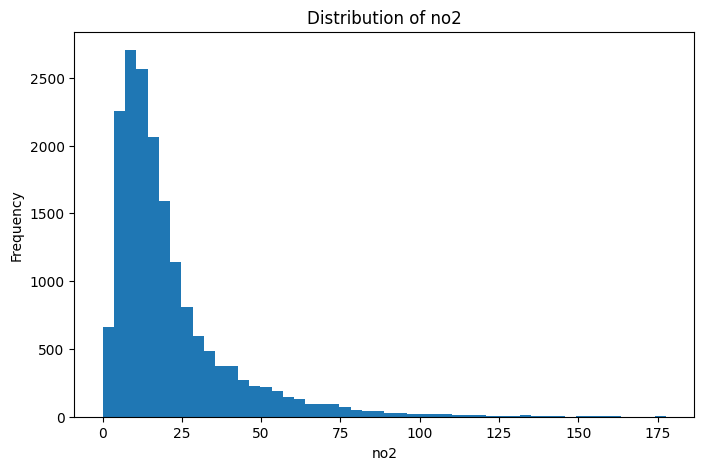

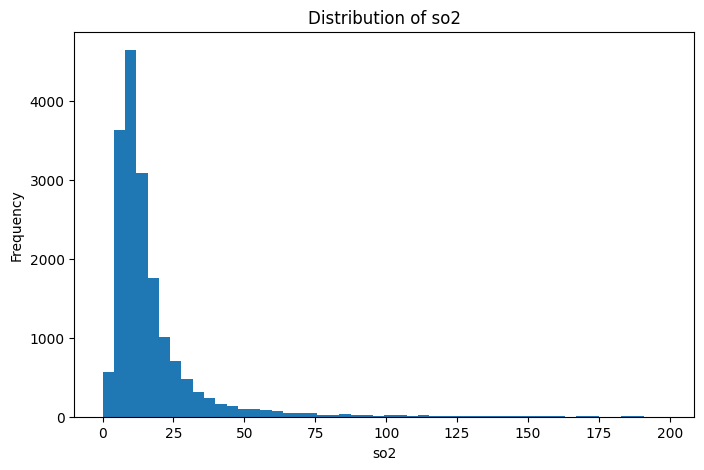

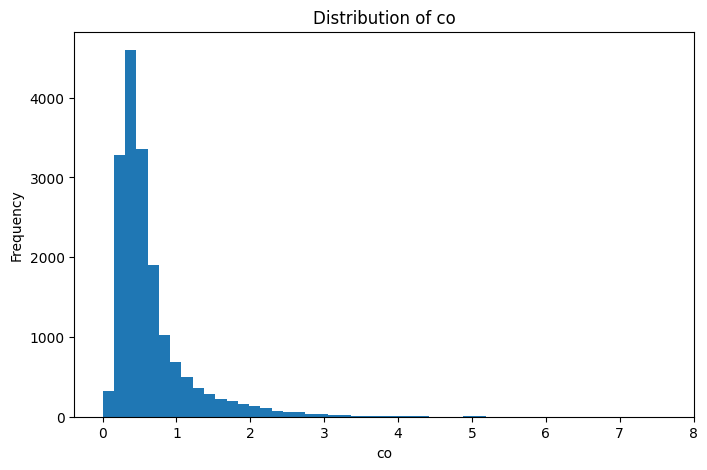

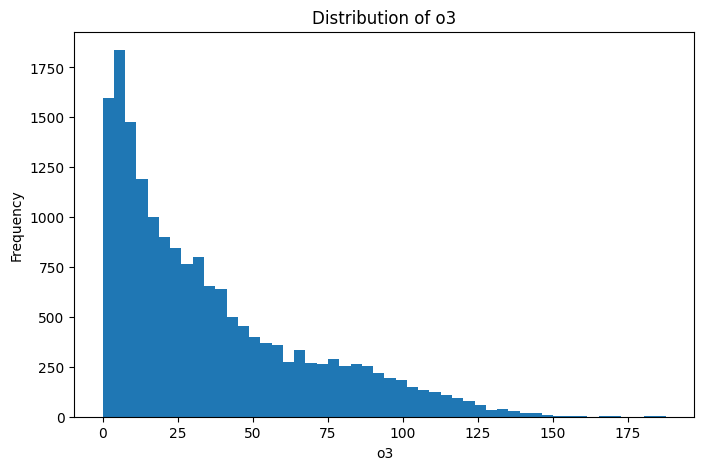

In [98]:
for pollutant in pollutants:
    plt.figure(figsize=(8, 5))
    plt.hist(data[pollutant], bins=50)
    plt.xlabel(pollutant)
    plt.ylabel("Frequency")
    plt.title(f"Distribution of {pollutant}")
    plt.show()

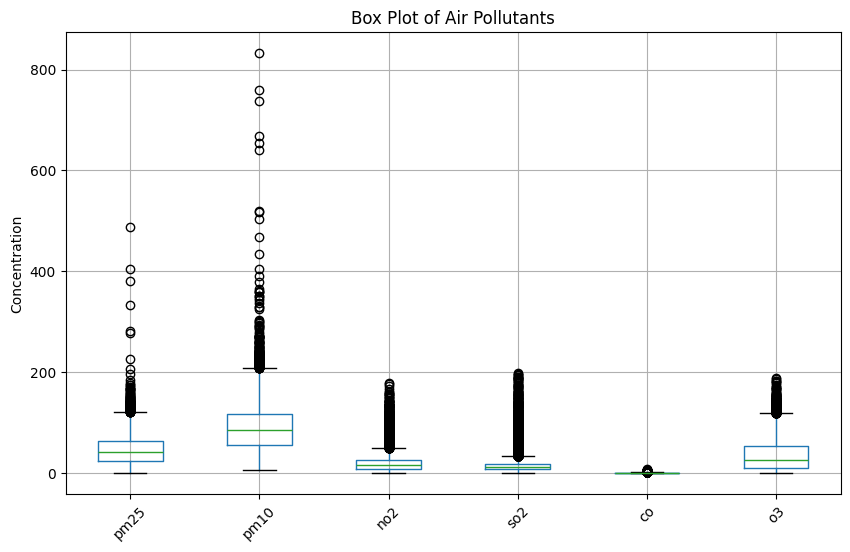

In [99]:
plt.figure(figsize=(10, 6))

data[pollutants].boxplot()

plt.title("Box Plot of Air Pollutants")
plt.ylabel("Concentration")
plt.xticks(rotation=45)
plt.show()

In [100]:
correlation_columns = [
    "pm25",
    "pm10",
    "no2",
    "so2",
    "co",
    "o3",
    "temperature",
    "humidity",
    "wind_speed",
    "wind_direction"
]
correlation_matrix = data[correlation_columns].corr()

print(correlation_matrix.round(2))

                pm25  pm10   no2   so2    co    o3  temperature  humidity  \
pm25            1.00  0.89  0.44  0.29  0.41  0.23        -0.26     -0.31   
pm10            0.89  1.00  0.46  0.27  0.44  0.19        -0.18     -0.31   
no2             0.44  0.46  1.00  0.28  0.76 -0.05        -0.05     -0.34   
so2             0.29  0.27  0.28  1.00  0.04  0.44         0.12     -0.41   
co              0.41  0.44  0.76  0.04  1.00 -0.26        -0.13     -0.11   
o3              0.23  0.19 -0.05  0.44 -0.26  1.00         0.47     -0.67   
temperature    -0.26 -0.18 -0.05  0.12 -0.13  0.47         1.00     -0.53   
humidity       -0.31 -0.31 -0.34 -0.41 -0.11 -0.67        -0.53      1.00   
wind_speed     -0.31 -0.28 -0.20 -0.14 -0.20 -0.02         0.19      0.03   
wind_direction -0.19 -0.16 -0.11 -0.14 -0.11 -0.15         0.09      0.07   

                wind_speed  wind_direction  
pm25                 -0.31           -0.19  
pm10                 -0.28           -0.16  
no2              

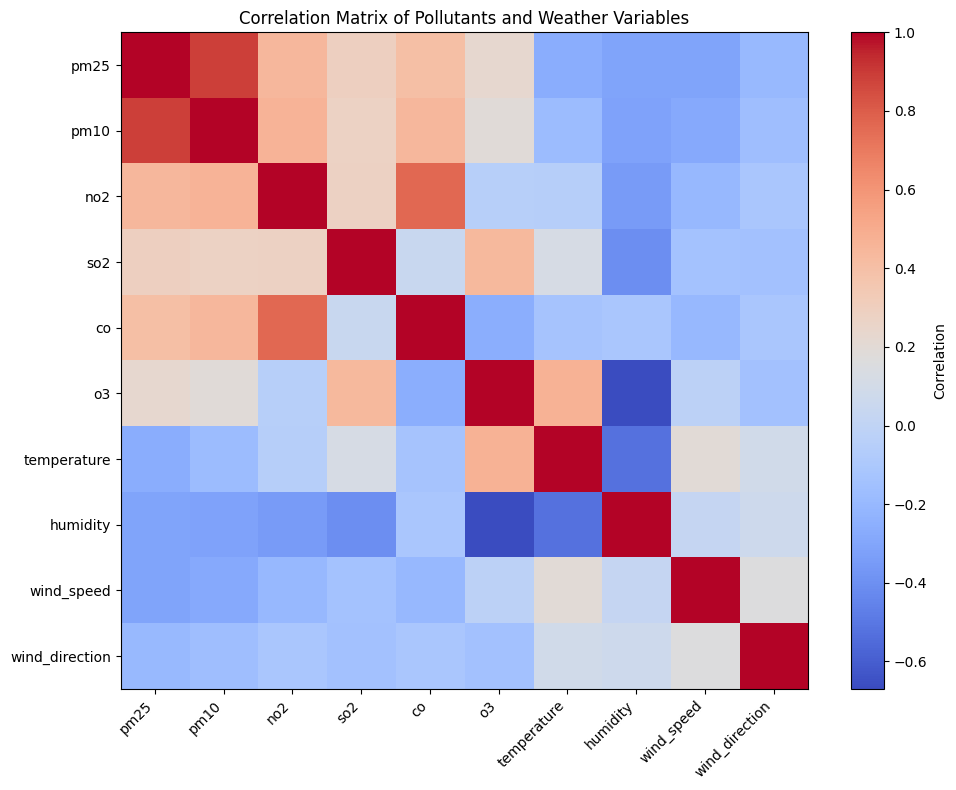

In [101]:
plt.figure(figsize=(10, 8))

plt.imshow(correlation_matrix, cmap="coolwarm", aspect="auto")

plt.colorbar(label="Correlation")

plt.xticks(range(len(correlation_columns)), correlation_columns, rotation=45, ha="right")

plt.yticks(range(len(correlation_columns)), correlation_columns)

plt.title("Correlation Matrix of Pollutants and Weather Variables")

plt.tight_layout()
plt.show()

In [102]:
hourly_pollution = data.groupby("hour")[pollutants].mean()

print(hourly_pollution.round(2))

       pm25    pm10    no2    so2    co     o3
hour                                          
0     54.12  106.72  20.16  12.95  0.60  22.05
1     51.98  100.73  16.49  12.88  0.53  23.11
2     48.95   94.36  13.93  12.73  0.46  23.60
3     47.08   88.58  12.59  12.31  0.42  23.65
4     45.11   83.74  11.75  12.12  0.39  23.22
5     43.33   79.48  11.69  11.75  0.39  22.35
6     42.19   77.23  13.38  11.69  0.44  20.87
7     42.04   77.77  14.97  11.83  0.51  21.79
8     42.74   80.28  15.62  13.92  0.54  31.77
9     42.96   84.78  16.11  16.53  0.55  44.10
10    43.83   87.92  16.71  20.01  0.54  53.43
11    44.73   89.76  16.58  23.52  0.48  60.78
12    44.97   90.02  16.29  26.56  0.43  65.43
13    44.11   88.76  15.42  26.59  0.40  67.56
14    42.86   86.43  15.28  25.62  0.39  68.70
15    41.98   84.41  15.51  25.30  0.39  67.12
16    41.00   82.62  18.68  23.45  0.47  60.70
17    40.36   82.71  27.29  20.22  0.69  46.56
18    42.00   87.17  38.59  17.45  1.07  28.91
19    45.48  

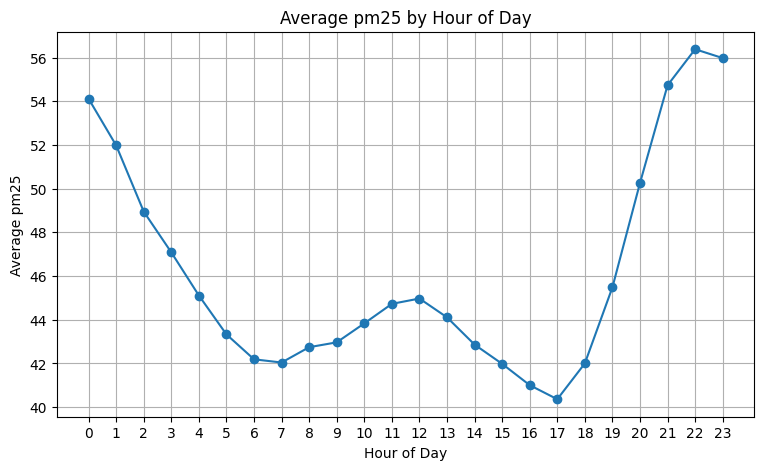

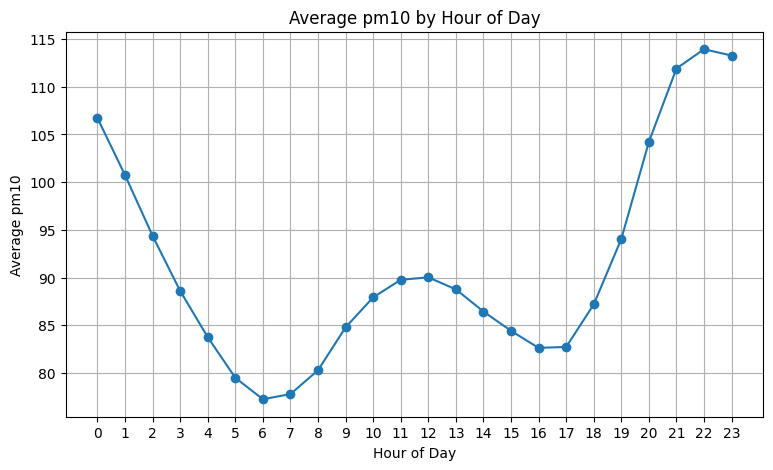

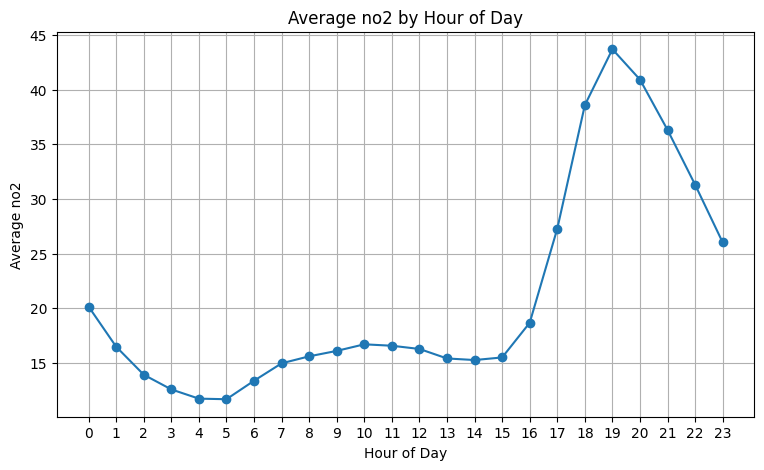

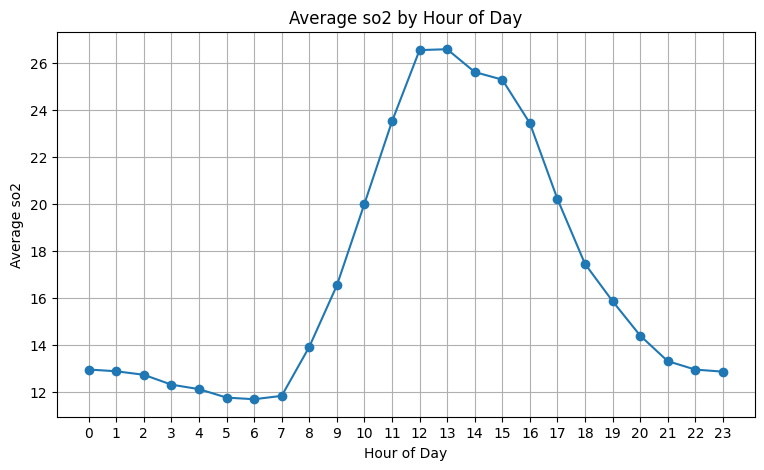

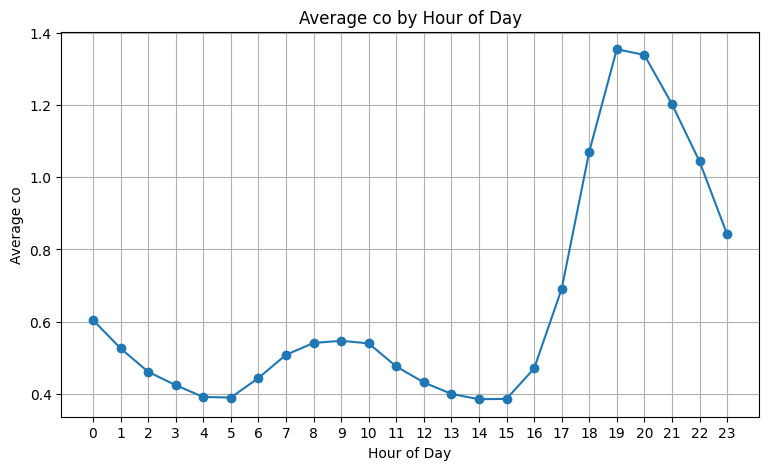

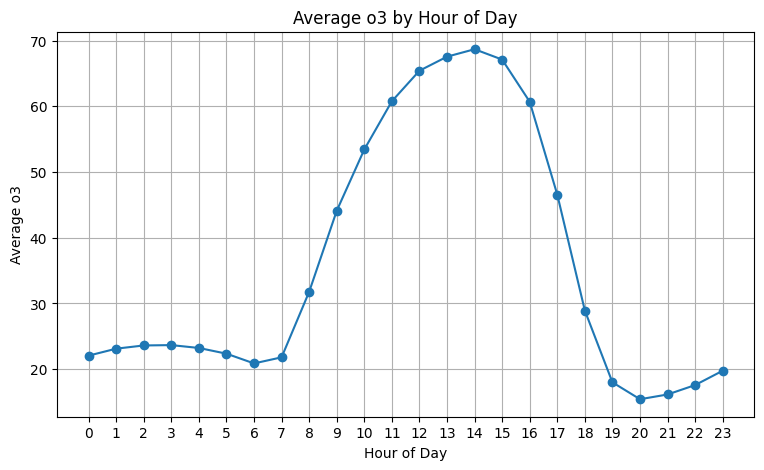

In [103]:
for pollutant in pollutants:
    plt.figure(figsize=(9, 5))
    
    plt.plot(hourly_pollution.index, hourly_pollution[pollutant], marker="o")
    
    plt.xlabel("Hour of Day")
    plt.ylabel(f"Average {pollutant}")
    plt.title(f"Average {pollutant} by Hour of Day")
    plt.xticks(range(24))
    plt.grid(True)
    plt.show()

In [104]:
monthly_pollution = data.groupby("month")[pollutants].mean()

print(monthly_pollution.round(2))

        pm25    pm10    no2    so2    co     o3
month                                          
1      74.97  134.20  35.12  23.64  0.98  43.01
2      56.81  108.33  34.65  24.92  0.72  51.33
3      56.13  107.96  30.36  24.32  0.72  56.78
4      50.31   98.39  26.41  18.10  0.69  53.65
5      40.30   79.20  19.44  14.53  0.55  48.69
6      29.17   61.58  14.47  13.43  0.48  35.13
7      19.87   54.06  10.72   6.45  0.50  10.18
8      20.84   51.61   9.18   7.46  0.47   9.51
9      23.01   57.94   9.42   8.71  0.46  14.76
10     46.12  102.82  13.72  13.84  0.55  26.33
11     71.92  125.32  22.50  23.47  0.80  45.54
12     66.13  115.37  27.64  25.15  0.82  37.92


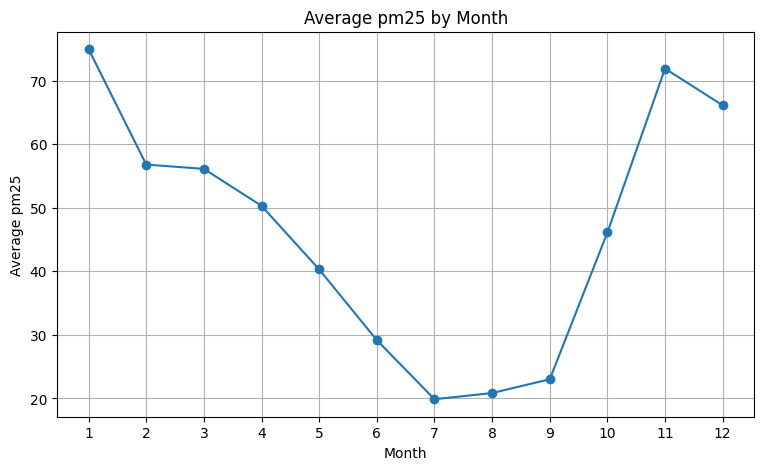

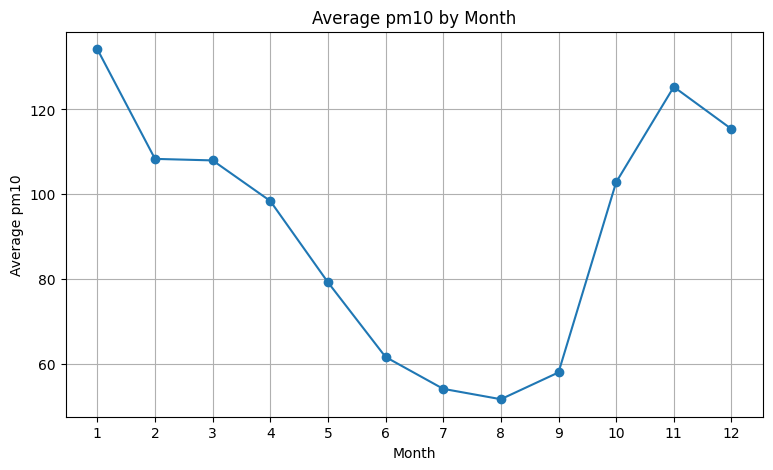

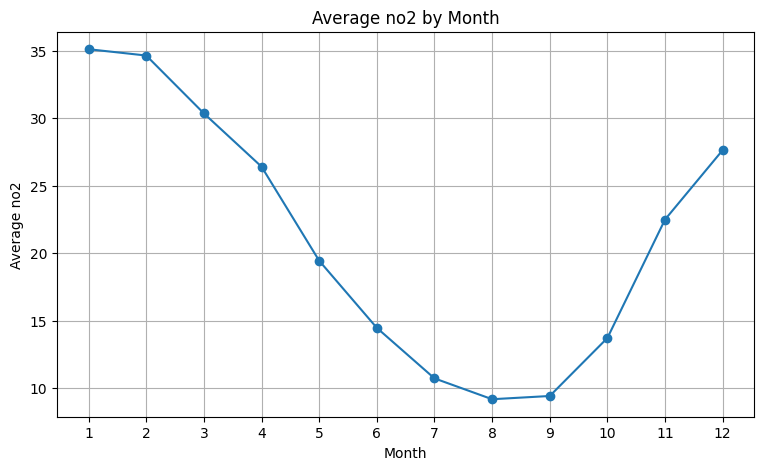

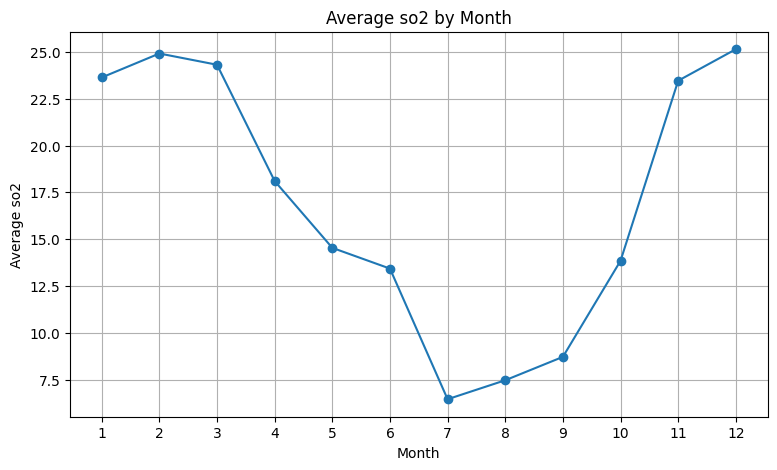

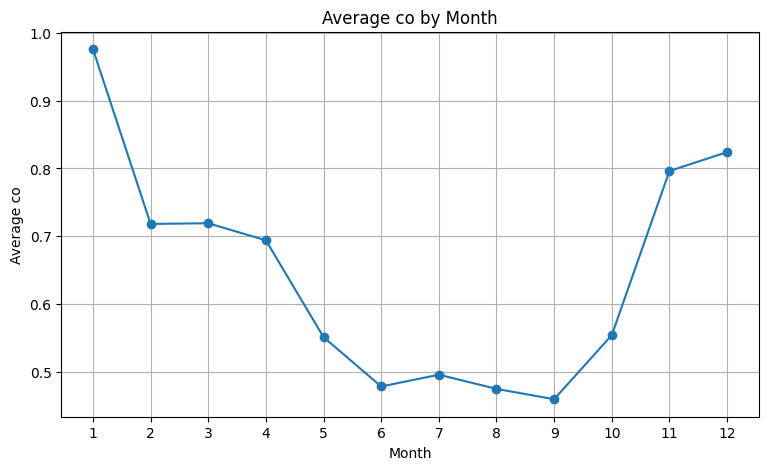

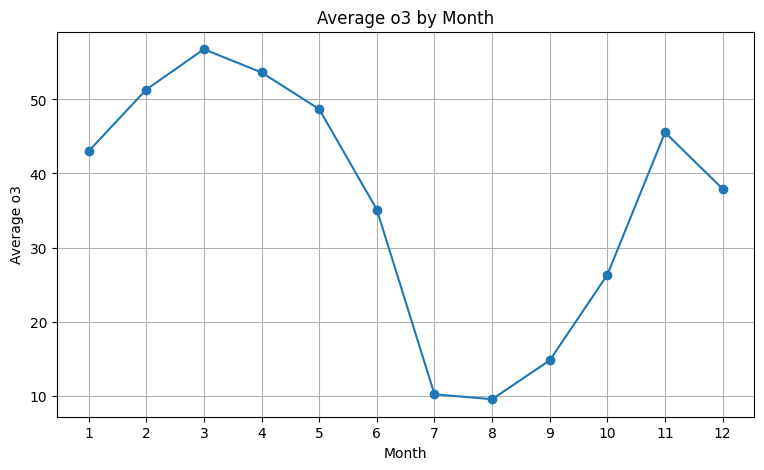

In [105]:
for pollutant in pollutants:
    plt.figure(figsize=(9, 5))

    plt.plot(monthly_pollution.index, monthly_pollution[pollutant], marker="o")

    plt.xlabel("Month")
    plt.ylabel(f"Average {pollutant}")
    plt.title(f"Average {pollutant} by Month")
    plt.xticks(range(1, 13))
    plt.grid(True)
    plt.show()

In [106]:
seasonal_pollution = data.groupby("season")[pollutants].mean()

print(seasonal_pollution.round(2))

               pm25    pm10    no2    so2    co     o3
season                                                
Monsoon       23.18   56.24  10.93   8.98  0.48  17.27
Post-Monsoon  58.81  113.88  18.03  18.58  0.67  35.78
Summer        48.90   95.15  25.39  19.00  0.65  53.03
Winter        66.17  119.52  32.39  24.56  0.84  43.89


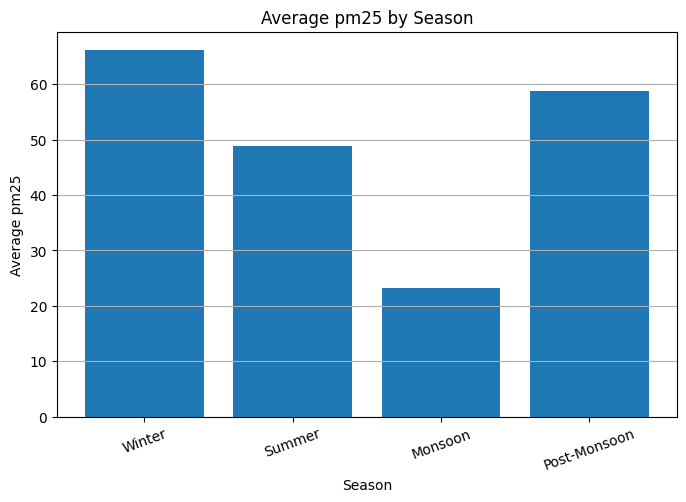

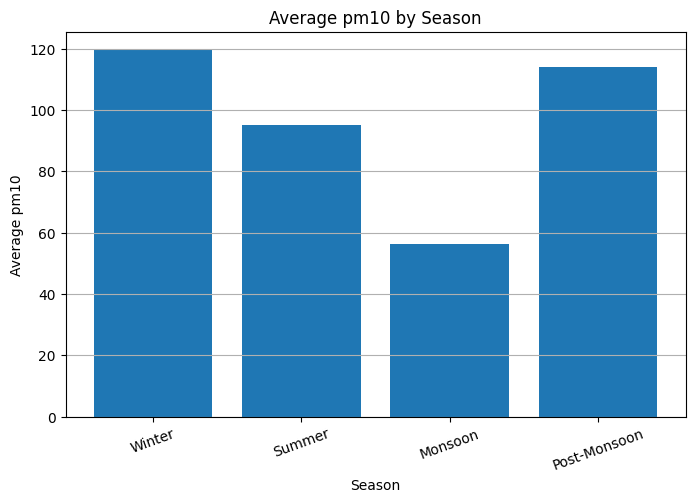

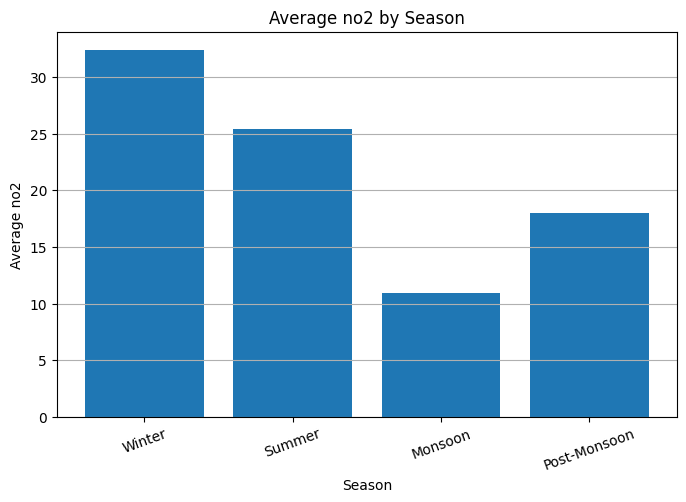

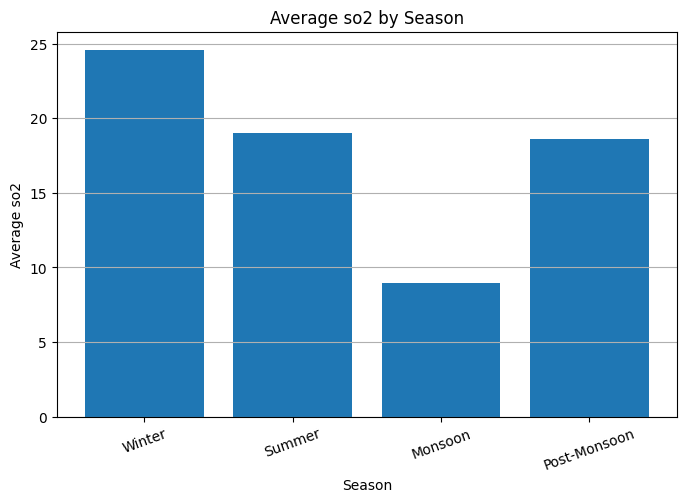

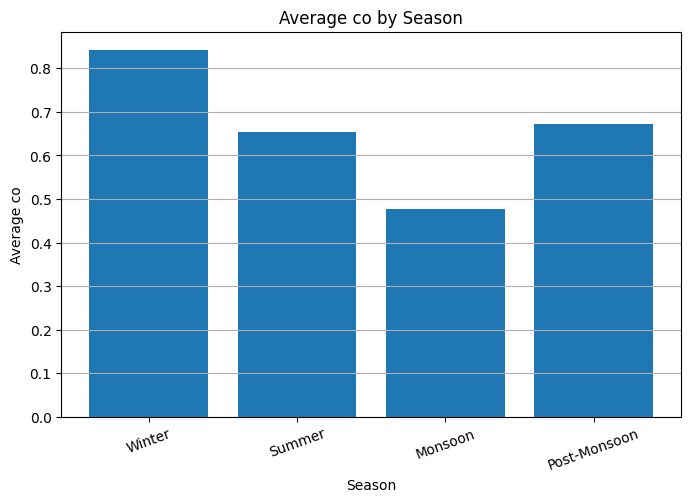

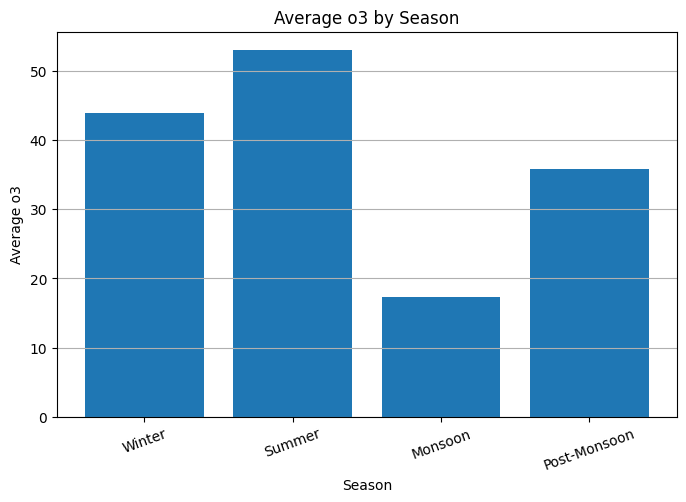

In [107]:
season_order = ["Winter", "Summer", "Monsoon", "Post-Monsoon"]

seasonal_pollution = seasonal_pollution.reindex(season_order)

for pollutant in pollutants:
    plt.figure(figsize=(8, 5))

    plt.bar(seasonal_pollution.index, seasonal_pollution[pollutant])

    plt.xlabel("Season")
    plt.ylabel(f"Average {pollutant}")
    plt.title(f"Average {pollutant} by Season")
    plt.xticks(rotation=20)
    plt.grid(axis="y")
    plt.show()

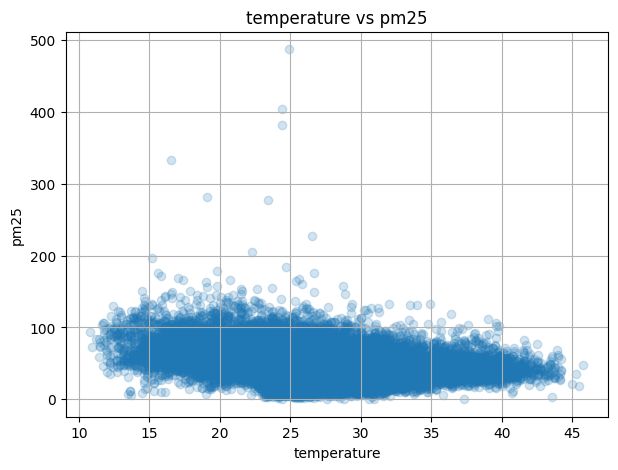

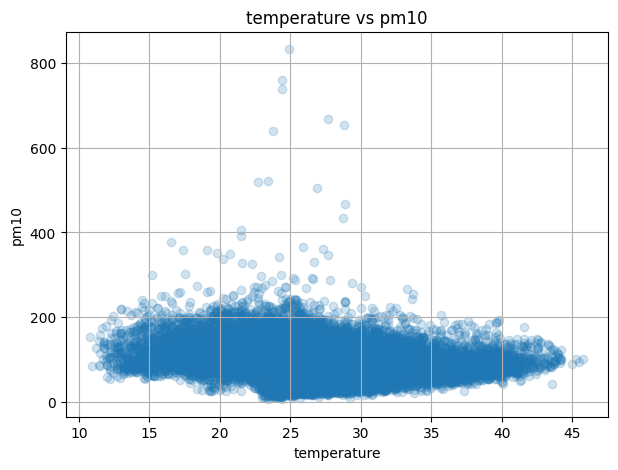

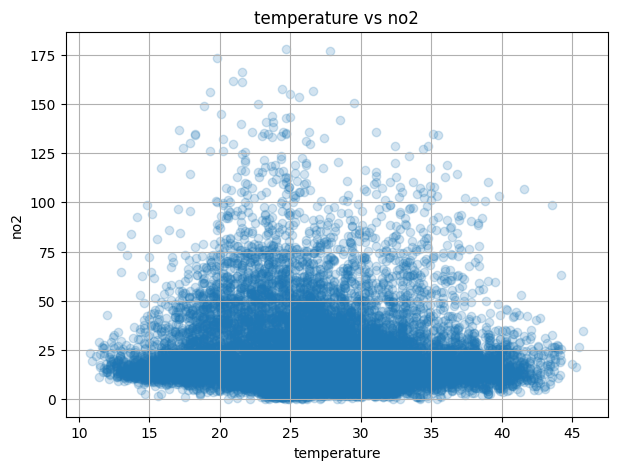

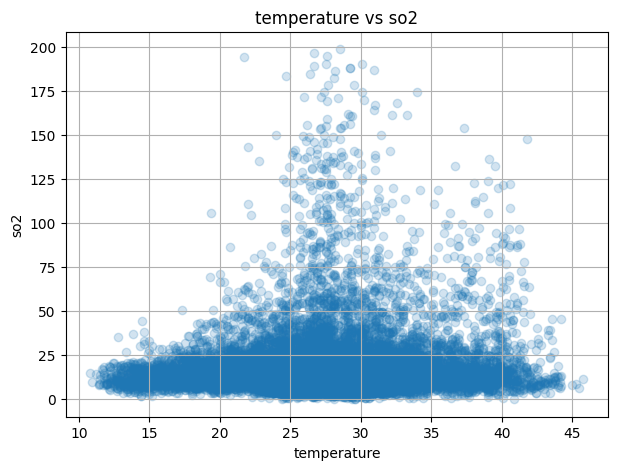

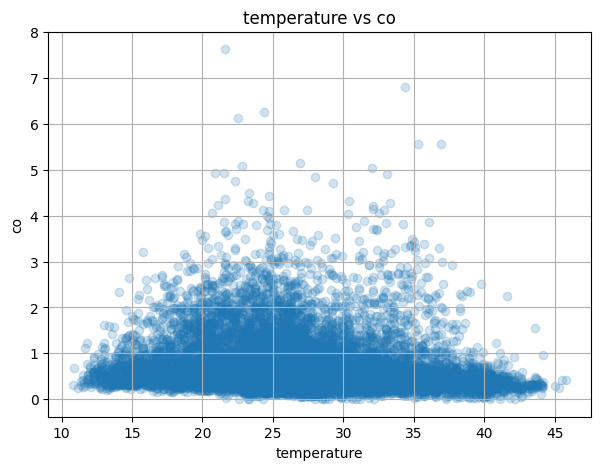

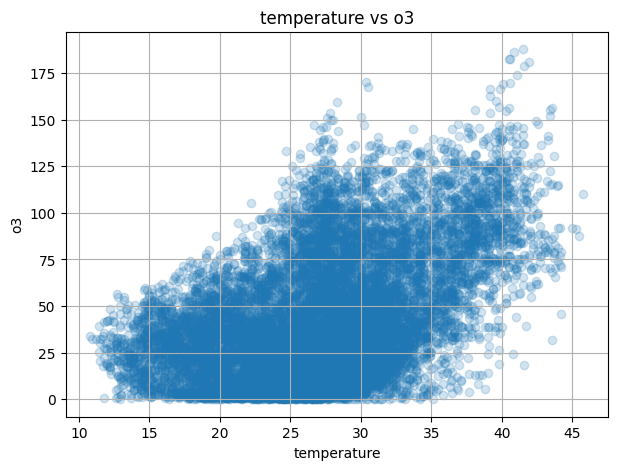

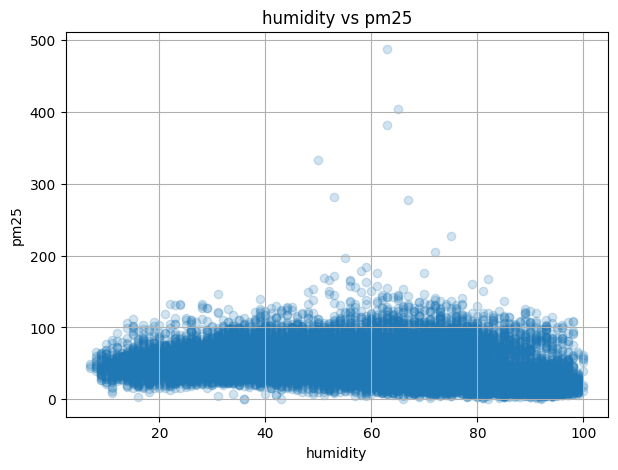

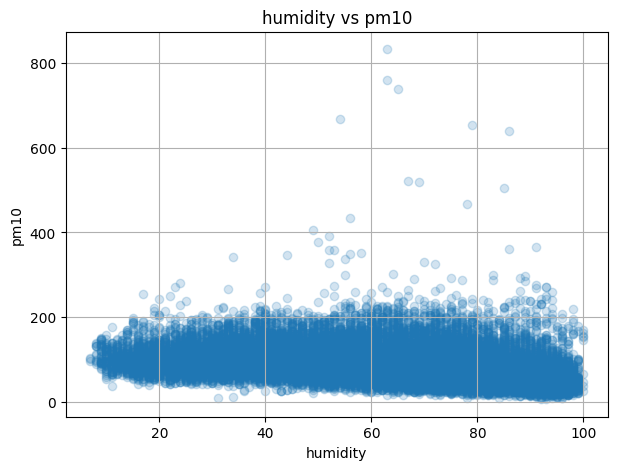

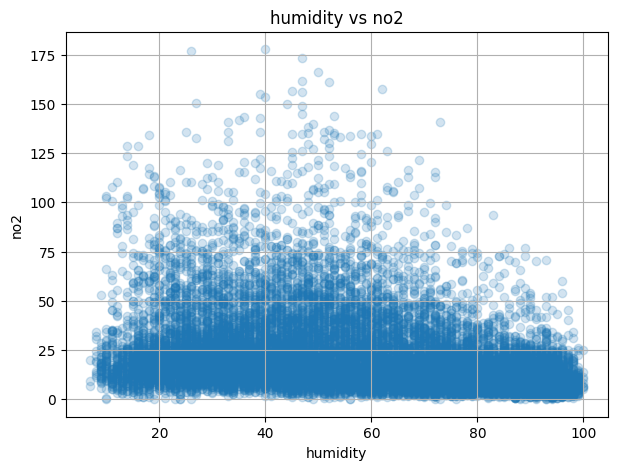

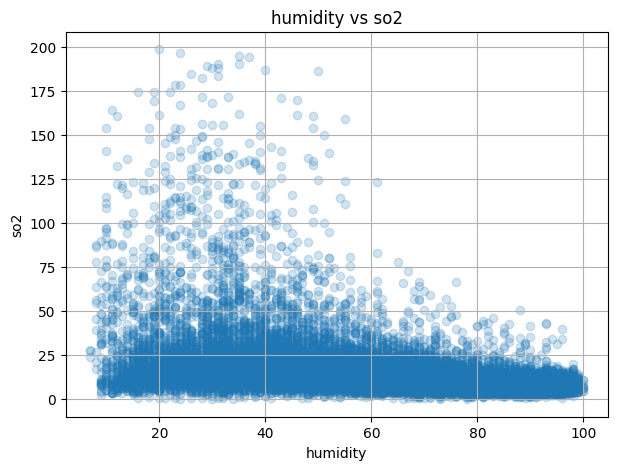

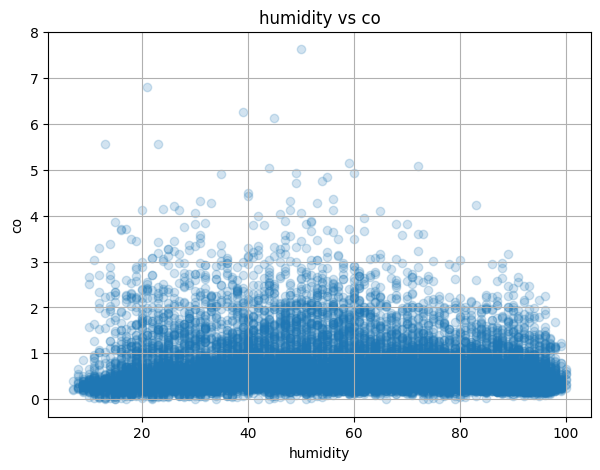

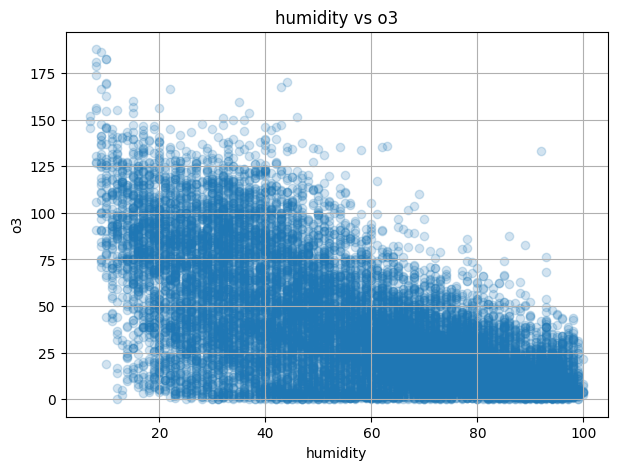

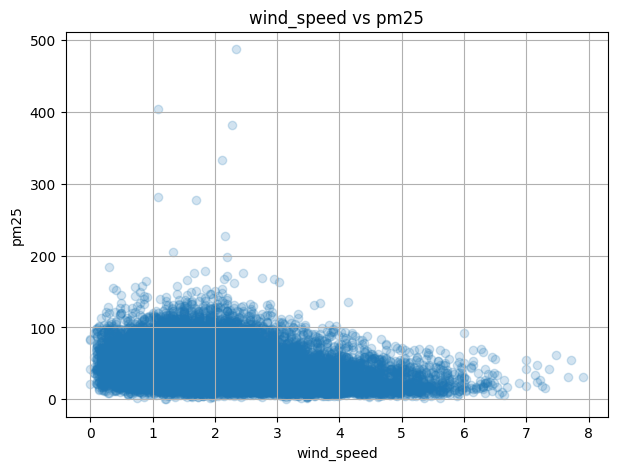

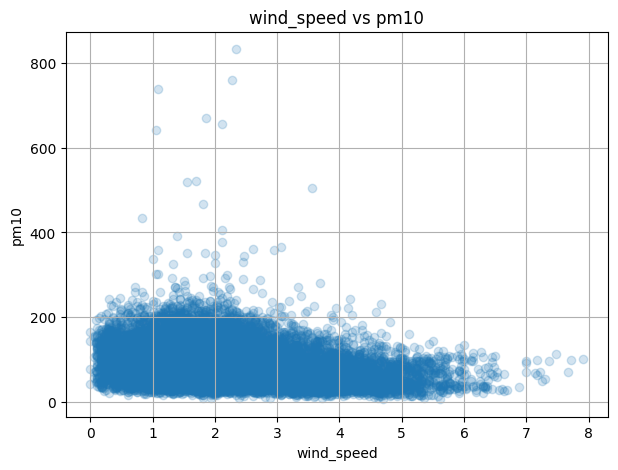

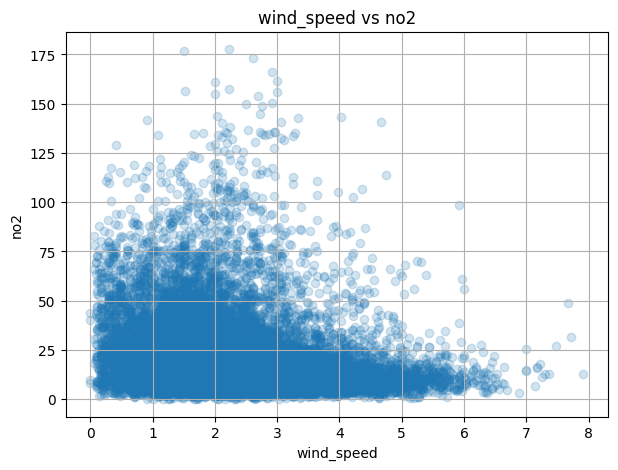

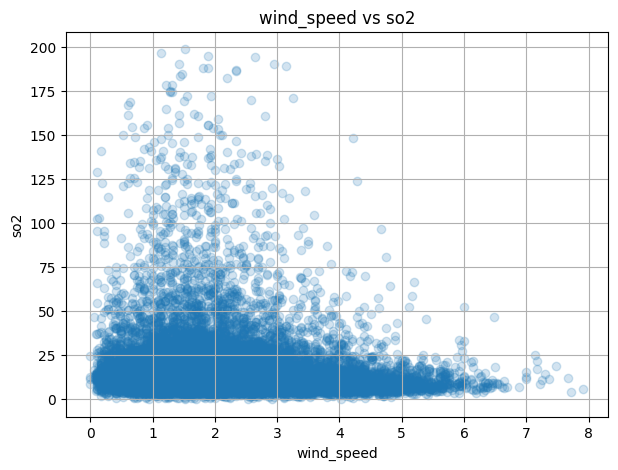

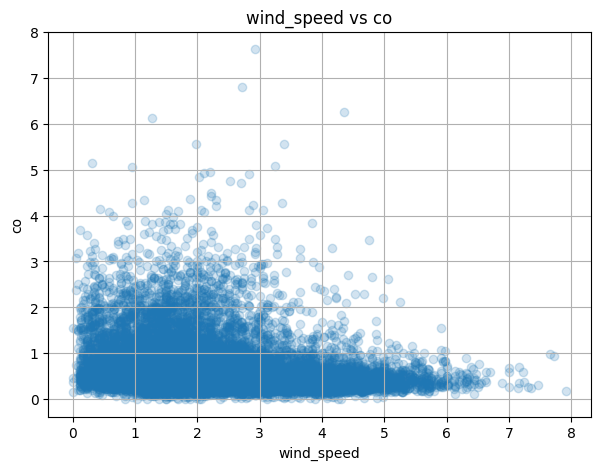

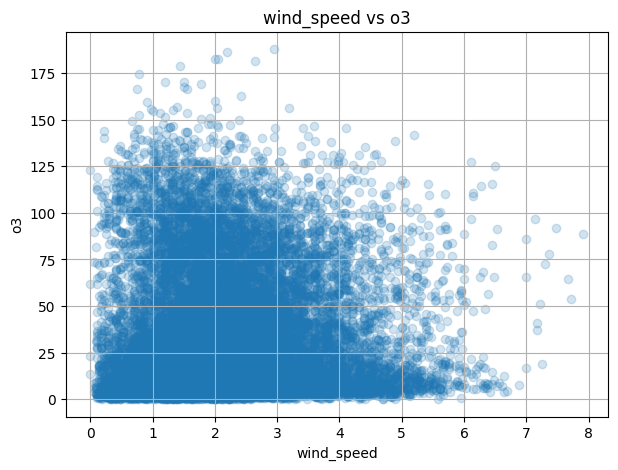

In [108]:
weather_variables = [
    "temperature",
    "humidity",
    "wind_speed"
]

for weather_var in weather_variables:
    for pollutant in pollutants:
        plt.figure(figsize=(7, 5))

        plt.scatter(
            data[weather_var],
            data[pollutant],
            alpha=0.2
        )

        plt.xlabel(weather_var)
        plt.ylabel(pollutant)
        plt.title(f"{weather_var} vs {pollutant}")
        plt.grid(True)
        plt.show()

In [109]:
weather_pollution_corr = data[weather_variables + pollutants].corr()

print(weather_pollution_corr.loc[weather_variables, pollutants].round(2))

             pm25  pm10   no2   so2    co    o3
temperature -0.26 -0.18 -0.05  0.12 -0.13  0.47
humidity    -0.31 -0.31 -0.34 -0.41 -0.11 -0.67
wind_speed  -0.31 -0.28 -0.20 -0.14 -0.20 -0.02


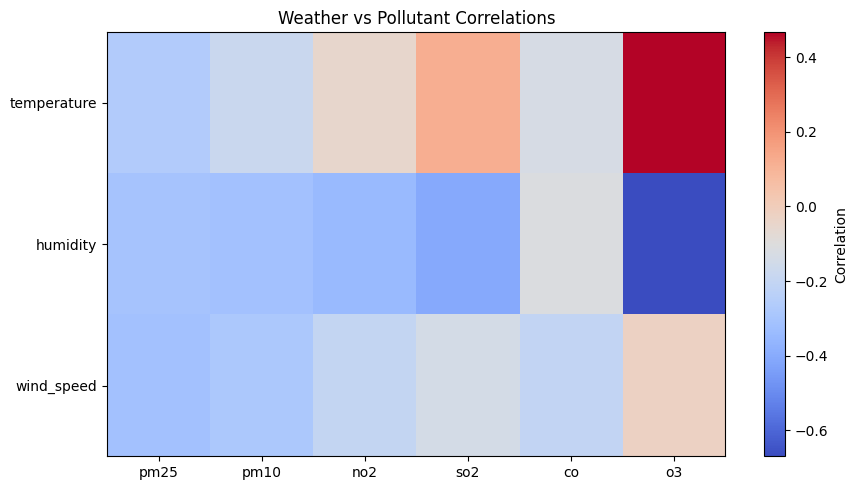

In [110]:
plt.figure(figsize=(9, 5))

plt.imshow(weather_pollution_corr.loc[weather_variables, pollutants], cmap="coolwarm", aspect="auto")

plt.colorbar(label="Correlation")

plt.xticks(range(len(pollutants)), pollutants)

plt.yticks(range(len(weather_variables)), weather_variables)

plt.title("Weather vs Pollutant Correlations")

plt.tight_layout()
plt.show()

In [111]:
targets = [
    "target_pm25",
    "target_pm10",
    "target_no2",
    "target_so2",
    "target_co",
    "target_o3"
]
predictor_features = [
    "pm25",
    "pm10",
    "no2",
    "so2",
    "co",
    "o3",
    "temperature",
    "humidity",
    "wind_speed",
    "wind_direction",
    "hour",
    "day",
    "day_of_week",
    "month",
    "year",
    "is_weekend",
    "wind_direction_sin",
    "wind_direction_cos",
    "month_sin",
    "month_cos",
    "hour_sin",
    "hour_cos"
]

predictor_features += [col for col in data.columns if "lag_" in col or "rolling_mean_" in col]
print("Number of predictor features:", len(predictor_features))

Number of predictor features: 61


In [112]:
feature_target_corr = data[predictor_features + targets].corr()

feature_target_corr = feature_target_corr.loc[predictor_features, targets]

print(feature_target_corr.round(2))

                    target_pm25  target_pm10  target_no2  target_so2  \
pm25                       0.95         0.84        0.38        0.28   
pm10                       0.86         0.93        0.38        0.25   
no2                        0.51         0.54        0.86        0.21   
so2                        0.30         0.29        0.30        0.78   
co                         0.49         0.55        0.63        0.02   
...                         ...          ...         ...         ...   
co_rolling_mean_6          0.57         0.57        0.21       -0.01   
co_rolling_mean_24         0.65         0.62        0.39        0.21   
o3_rolling_mean_3          0.22         0.20        0.35        0.41   
o3_rolling_mean_6          0.30         0.29        0.51        0.36   
o3_rolling_mean_24         0.52         0.46        0.36        0.33   

                    target_co  target_o3  
pm25                     0.32       0.25  
pm10                     0.34       0.21  
no2   

In [113]:
for target in targets:
    print(f"\nTop correlations with {target}:")
    
    correlations = (feature_target_corr[target].abs().sort_values(ascending=False).head(10))
    
    print(correlations)


Top correlations with target_pm25:
pm25                    0.948612
pm25_lag_1              0.894485
pm25_rolling_mean_3     0.863350
pm10                    0.859611
pm25_rolling_mean_6     0.831942
pm10_lag_1              0.816284
pm25_rolling_mean_24    0.810098
pm25_rolling_mean_12    0.801280
pm10_rolling_mean_3     0.799611
pm25_lag_3              0.794376
Name: target_pm25, dtype: float64

Top correlations with target_pm10:
pm10                    0.931391
pm10_lag_1              0.858343
pm25                    0.842472
pm10_rolling_mean_3     0.820658
pm25_lag_1              0.789436
pm10_rolling_mean_6     0.778138
pm10_rolling_mean_24    0.765795
pm25_rolling_mean_3     0.753855
pm25_rolling_mean_6     0.719616
pm25_rolling_mean_24    0.716253
Name: target_pm10, dtype: float64

Top correlations with target_no2:
no2                    0.863792
no2_lag_1              0.699897
no2_lag_24             0.674511
co                     0.625605
o3_lag_6               0.603336
no2_r

In [114]:
top_features = (feature_target_corr.abs().max(axis=1).sort_values(ascending=False).index)

print(top_features)

Index(['pm25', 'pm10', 'o3', 'pm25_lag_1', 'no2', 'pm25_rolling_mean_3',
       'pm10_lag_1', 'pm25_rolling_mean_6', 'pm10_rolling_mean_3',
       'pm25_rolling_mean_24', 'o3_lag_1', 'o3_lag_24', 'pm25_rolling_mean_12',
       'co', 'pm25_lag_3', 'so2', 'pm10_rolling_mean_6',
       'pm10_rolling_mean_24', 'pm25_lag_24', 'pm25_lag_6', 'no2_lag_1',
       'o3_rolling_mean_3', 'no2_lag_24', 'pm10_lag_24', 'co_rolling_mean_24',
       'pm25_lag_12', 'pm10_lag_6', 'humidity', 'no2_rolling_mean_24',
       'o3_lag_6', 'no2_rolling_mean_3', 'co_rolling_mean_3',
       'no2_rolling_mean_6', 'co_lag_1', 'co_rolling_mean_6', 'so2_lag_1',
       'o3_rolling_mean_24', 'so2_rolling_mean_24', 'month_cos', 'co_lag_24',
       'o3_rolling_mean_6', 'hour_cos', 'so2_rolling_mean_3',
       'so2_rolling_mean_6', 'month_sin', 'no2_lag_6', 'so2_lag_24',
       'temperature', 'hour_sin', 'so2_lag_6', 'hour', 'wind_direction_sin',
       'co_lag_6', 'wind_speed', 'month', 'wind_direction_cos',
       'wind_

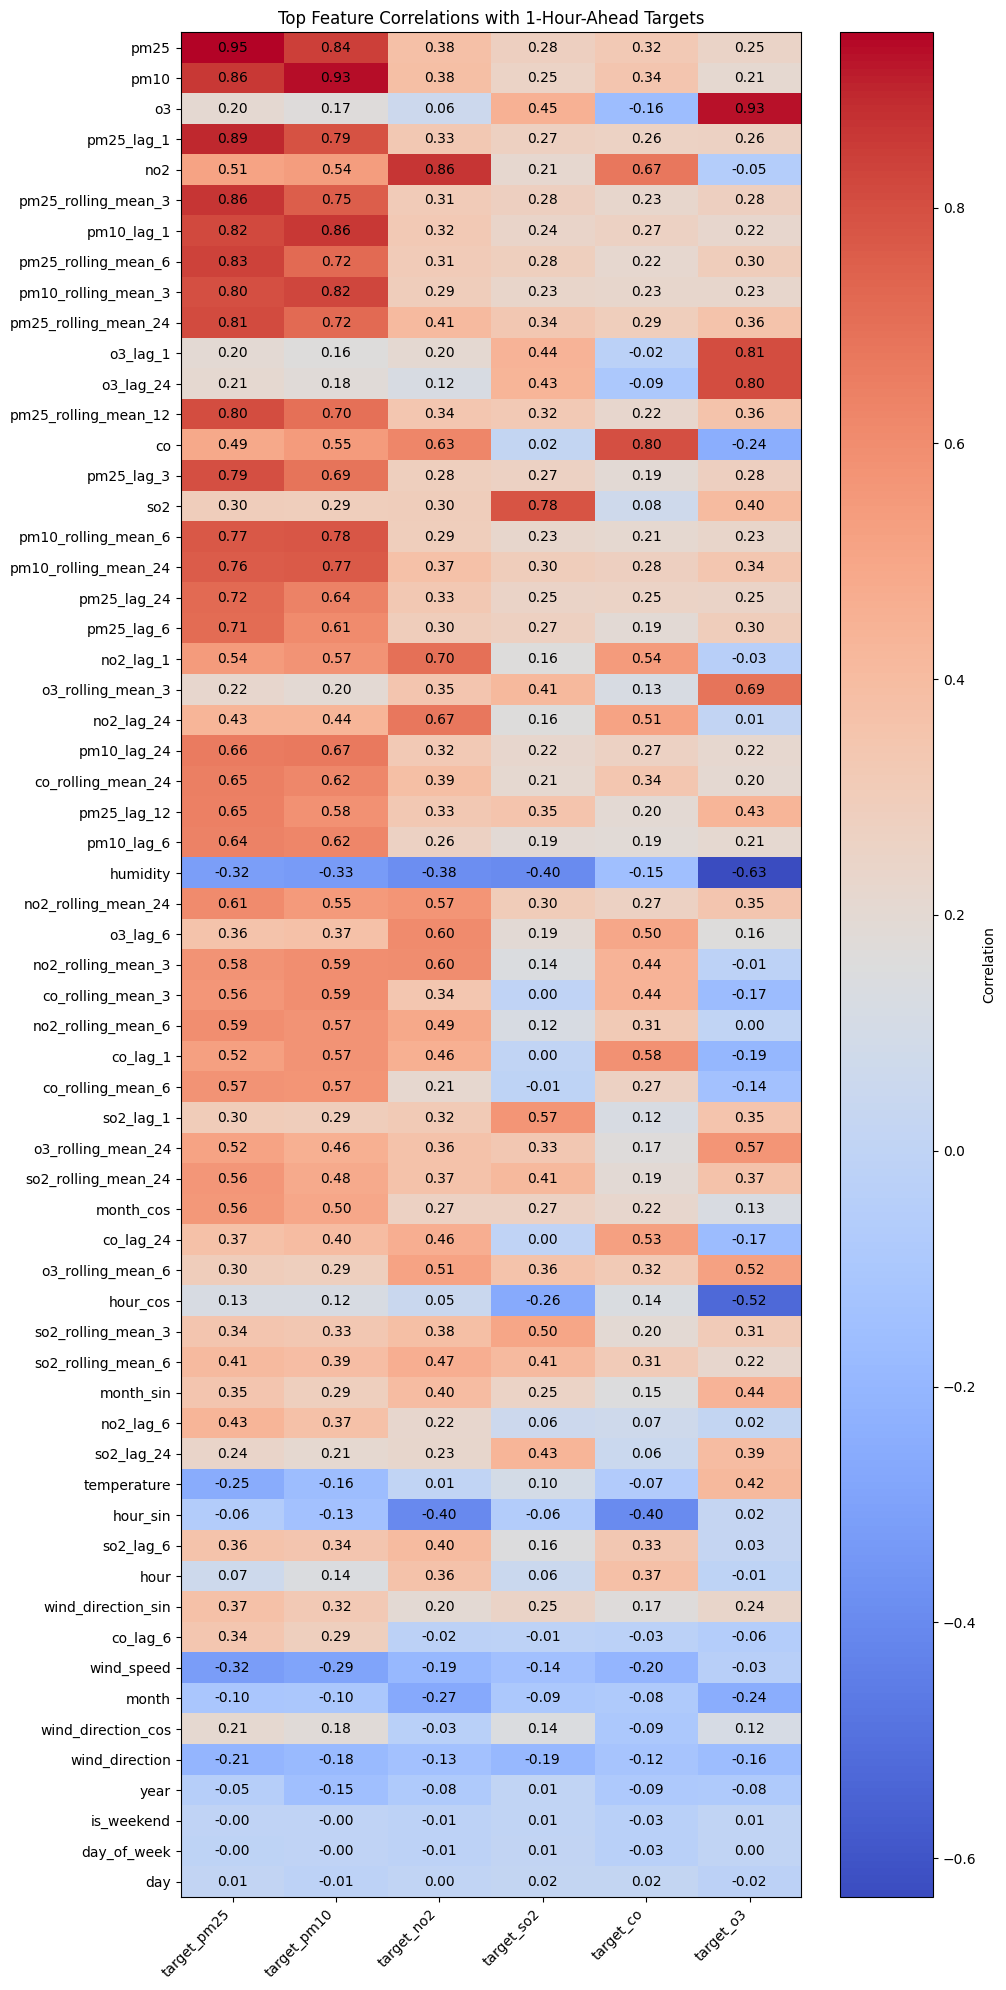

In [115]:
plt.figure(figsize=(10, 20))

correlation_values = feature_target_corr.loc[top_features, targets]

plt.imshow(feature_target_corr.loc[top_features, targets], cmap="coolwarm", aspect="auto")

plt.colorbar(label="Correlation")

plt.xticks(range(len(targets)), targets, rotation=45, ha="right")

plt.yticks(range(len(top_features)), top_features)

for i in range(len(top_features)):
    for j in range(len(targets)):
        plt.text(j, i, f"{correlation_values.iloc[i, j]:.2f}", ha="center", va="center")

plt.title("Top Feature Correlations with 1-Hour-Ahead Targets")

plt.tight_layout()
plt.show()

In [116]:
# Current pm25 → 0.95
# pm25_lag_1 → 0.89
# pm25_rolling_mean_3 → 0.86
# pm25_rolling_mean_6 → 0.83
# pm25_rolling_mean_24 → 0.81

# PM10 prediction
# Strongest:
# - Current pm10 → 0.93
# - pm10_lag_1 → 0.86
# - Current pm25 → 0.84
# - pm10_rolling_mean_3 → 0.82
# - pm10_rolling_mean_6 → 0.78

# NO₂ prediction
# Interesting pattern:
# - Current no2 → 0.86
# - no2_lag_1 → 0.70
# - no2_lag_24 → 0.67
# - o3_lag_6 → 0.60
# - no2_rolling_mean_3 → 0.60

# SO₂ prediction
# Strong relationships include:
# - Current so2 → 0.78
# - so2_lag_1 → 0.57
# - so2_rolling_mean_3 → 0.50
# - so2_lag_24 → 0.43
# - so2_rolling_mean_6 → 0.41

# CO prediction
# Strongest:
# - Current co → 0.80
# - pm10 → 0.34
# - pm25 → 0.32
# - no2_lag_1 → 0.54
# - no2_lag_24 → 0.51

# O₃ prediction
# O₃ is particularly interesting:
# - Current o3 → 0.93
# - o3_lag_1 → 0.81
# - o3_lag_24 → 0.80
# - o3_rolling_mean_3 → 0.69
# - o3_rolling_mean_24 → 0.57
# - humidity → -0.63
# - hour_cos → -0.52

In [117]:
pollutants = [
    "pm25",
    "pm10",
    "no2",
    "so2",
    "co",
    "o3"
]

targets = [
    "target_pm25",
    "target_pm10",
    "target_no2",
    "target_so2",
    "target_co",
    "target_o3"
]

In [118]:
feature_target_corr = data.corr(numeric_only=True)

correlation_threshold = 0.55

In [119]:
selected_lag_features = []

for pollutant in pollutants:
    target = f"target_{pollutant}"
    lag_features = [col for col in data.columns if col.startswith(f"{pollutant}_lag_")]

    for feature in lag_features:
        corr = feature_target_corr.loc[feature, target]

        if abs(corr) >= correlation_threshold:
            selected_lag_features.append(feature)
            print(f"{feature:25s} → {target:15s} " f"correlation = {corr:.2f}")

pm25_lag_1                → target_pm25     correlation = 0.89
pm25_lag_3                → target_pm25     correlation = 0.79
pm25_lag_6                → target_pm25     correlation = 0.71
pm25_lag_12               → target_pm25     correlation = 0.65
pm25_lag_24               → target_pm25     correlation = 0.72
pm10_lag_1                → target_pm10     correlation = 0.86
pm10_lag_6                → target_pm10     correlation = 0.62
pm10_lag_24               → target_pm10     correlation = 0.67
no2_lag_1                 → target_no2      correlation = 0.70
no2_lag_24                → target_no2      correlation = 0.67
so2_lag_1                 → target_so2      correlation = 0.57
co_lag_1                  → target_co       correlation = 0.58
o3_lag_1                  → target_o3       correlation = 0.81
o3_lag_24                 → target_o3       correlation = 0.80


In [120]:
selected_rolling_features = []

for pollutant in pollutants:
    target = f"target_{pollutant}"
    rolling_features = [col for col in data.columns if col.startswith(f"{pollutant}_rolling_mean_")]

    for feature in rolling_features:
        corr = feature_target_corr.loc[feature, target]

        if abs(corr) >= correlation_threshold:
            selected_rolling_features.append(feature)
            print(f"{feature:30s} → {target:15s} "  f"correlation = {corr:.2f}")

pm25_rolling_mean_3            → target_pm25     correlation = 0.86
pm25_rolling_mean_6            → target_pm25     correlation = 0.83
pm25_rolling_mean_12           → target_pm25     correlation = 0.80
pm25_rolling_mean_24           → target_pm25     correlation = 0.81
pm10_rolling_mean_3            → target_pm10     correlation = 0.82
pm10_rolling_mean_6            → target_pm10     correlation = 0.78
pm10_rolling_mean_24           → target_pm10     correlation = 0.77
no2_rolling_mean_3             → target_no2      correlation = 0.60
no2_rolling_mean_24            → target_no2      correlation = 0.57
o3_rolling_mean_3              → target_o3       correlation = 0.69
o3_rolling_mean_24             → target_o3       correlation = 0.57


In [121]:
print("\nSelected LAG features:")
for feature in selected_lag_features:
    print(feature)

print("\nSelected ROLLING features:")
for feature in selected_rolling_features:
    print(feature)


Selected LAG features:
pm25_lag_1
pm25_lag_3
pm25_lag_6
pm25_lag_12
pm25_lag_24
pm10_lag_1
pm10_lag_6
pm10_lag_24
no2_lag_1
no2_lag_24
so2_lag_1
co_lag_1
o3_lag_1
o3_lag_24

Selected ROLLING features:
pm25_rolling_mean_3
pm25_rolling_mean_6
pm25_rolling_mean_12
pm25_rolling_mean_24
pm10_rolling_mean_3
pm10_rolling_mean_6
pm10_rolling_mean_24
no2_rolling_mean_3
no2_rolling_mean_24
o3_rolling_mean_3
o3_rolling_mean_24


In [122]:
base_features = [
    "timestamp",

    # Current pollutant values
    "pm25",
    "pm10",
    "no2",
    "so2",
    "co",
    "o3",

    # Weather
    "temperature",
    "humidity",
    "wind_speed",
    "weather_code",

    # Cyclic time features
    "hour_sin",
    "hour_cos",
    "month_sin",
    "month_cos",

    # Cyclic wind direction
    "wind_direction_sin",
    "wind_direction_cos",

    # Other useful temporal/context feature
    "season"
]

In [123]:
selected_features = (base_features + selected_lag_features + selected_rolling_features)

# Remove accidental duplicates while preserving order
selected_features = list(dict.fromkeys(selected_features))

print("Total selected features:", len(selected_features))

print("\nSelected features:")
for feature in selected_features:
    print(feature)

Total selected features: 43

Selected features:
timestamp
pm25
pm10
no2
so2
co
o3
temperature
humidity
wind_speed
weather_code
hour_sin
hour_cos
month_sin
month_cos
wind_direction_sin
wind_direction_cos
season
pm25_lag_1
pm25_lag_3
pm25_lag_6
pm25_lag_12
pm25_lag_24
pm10_lag_1
pm10_lag_6
pm10_lag_24
no2_lag_1
no2_lag_24
so2_lag_1
co_lag_1
o3_lag_1
o3_lag_24
pm25_rolling_mean_3
pm25_rolling_mean_6
pm25_rolling_mean_12
pm25_rolling_mean_24
pm10_rolling_mean_3
pm10_rolling_mean_6
pm10_rolling_mean_24
no2_rolling_mean_3
no2_rolling_mean_24
o3_rolling_mean_3
o3_rolling_mean_24


In [124]:
selected_columns = selected_features + targets

selected_data = data[selected_columns].copy()

print("Selected dataset shape:", selected_data.shape)

Selected dataset shape: (17519, 49)


In [125]:
print("Missing values:", selected_data.isnull().sum().sum())

print(
    "Duplicate timestamps:",
    selected_data["timestamp"].duplicated().sum()
)

print("Rows:", len(selected_data))
print("Columns:", len(selected_data.columns))

Missing values: 0
Duplicate timestamps: 0
Rows: 17519
Columns: 49


In [126]:
selected_data.to_csv("../data/processed/Ambazari_Nagpur_Selected_Features_Dataset_2024_2025.csv", index=False)

print("Selected feature dataset saved successfully.")

Selected feature dataset saved successfully.
